In [25]:
from get_noise_sigma import load_dataset

dataset_name = ['TIMIT-sentence_type-16k', 'TIMIT-gender-16k', 'TIMIT-dialect-16k']
dataset_name = ['TIMIT-sentence_type-16k']
for dataset in dataset_name:
    data = load_dataset(dataset)

    import numpy as np 
    key1 = 'TRAIN'
    audio = {key1: {}}
    for key2 in data[key1].keys():
        audio[key1][key2] = {}
        for key3 in data[key1][key2].keys():
            l = [(10 ** (i / 10)).sum(axis=-1).mean() for i in data[key1][key2][key3]]
            audio[key1][key2][key3] = l
            if "FJSP0" in key3:
                d = [i for i in data[key1][key2][key3]]
                size_l = [[i.shape for i in data[key1][key2][key3]]]
                # print(l, np.mean(l), np.std(l))
                
                if len(size_l)>0:
                    print(l)
                    print(size_l)
    # audio

    key1 = 'TRAIN'
    s = []
    for key2 in audio[key1].keys():
        for key3 in audio[key1][key2].keys():
            s.append(np.mean(audio[key1][key2][key3]))
    np.mean(s)

    from get_noise_sigma import get_gaussian_sigma
    print(f'=========={dataset}==========')
    print("H, -15dB:", get_gaussian_sigma(np.mean(s), -20))
    print("H, -15dB:", get_gaussian_sigma(np.mean(s), -15))
    print("H, 0dB:", get_gaussian_sigma(np.mean(s), 0))
    print("M, 15dB:", get_gaussian_sigma(np.mean(s), 15)) 
    print("L, 25dB:", get_gaussian_sigma(np.mean(s), 25))

[0.5865394, 0.67150676, 0.47556317, 0.4730428, 0.56988645, 0.5005794, 0.3759934, 0.15124355, 0.61658335, 0.53292525]
[[(1, 439, 64), (1, 289, 64), (1, 124, 64), (1, 383, 64), (1, 289, 64), (1, 347, 64), (1, 269, 64), (1, 251, 64), (1, 358, 64), (1, 274, 64)]]
==========TIMIT-sentence_type-16k==========
H, -15dB: 5.2243327129946735
H, -15dB: 2.9378581810607165
H, 0dB: 0.5224332712994674
M, 15dB: 0.09290323294711213
L, 25dB: 0.029378581810607162


In [29]:
(10 ** (d[2] / 10)).sum(axis=-1).mean()

0.47556317

In [21]:
import numpy as np 

d = np.load('autrainer-configurations/data/TIMIT-sentence_type/log_mel_16k/TRAIN/DR1/FJSP0/SI1763.npy')
d.shape

(1, 124, 64)

In [7]:
data[key1][key2][key3][0]

array([[[-66.63042 , -73.305824, -71.27079 , ..., -74.84277 ,
         -75.548836, -73.677795],
        [-69.301056, -70.75253 , -73.69812 , ..., -77.08617 ,
         -75.10583 , -76.025406],
        [-64.58675 , -68.39219 , -71.196365, ..., -77.14436 ,
         -74.91669 , -75.98715 ],
        ...,
        [-70.7788  , -72.53138 , -74.578674, ..., -76.77527 ,
         -79.664825, -78.050415],
        [-64.76122 , -67.40239 , -69.33204 , ..., -77.51434 ,
         -79.49958 , -75.39704 ],
        [-69.98446 , -67.58452 , -63.267235, ..., -76.53399 ,
         -72.48188 , -71.63718 ]]], dtype=float32)

In [12]:
(10 ** (data[key1][key2][key3][0] / 10)).max()

0.04616595

In [15]:
data[key1][key2][key3][0]

array([[[-66.63042 , -73.305824, -71.27079 , ..., -74.84277 ,
         -75.548836, -73.677795],
        [-69.301056, -70.75253 , -73.69812 , ..., -77.08617 ,
         -75.10583 , -76.025406],
        [-64.58675 , -68.39219 , -71.196365, ..., -77.14436 ,
         -74.91669 , -75.98715 ],
        ...,
        [-70.7788  , -72.53138 , -74.578674, ..., -76.77527 ,
         -79.664825, -78.050415],
        [-64.76122 , -67.40239 , -69.33204 , ..., -77.51434 ,
         -79.49958 , -75.39704 ],
        [-69.98446 , -67.58452 , -63.267235, ..., -76.53399 ,
         -72.48188 , -71.63718 ]]], dtype=float32)

In [2]:
import autrainer 
autrainer.__file__

KeyboardInterrupt: 

In [7]:
np.mean(s)

0.27293652

In [6]:
snr_db = 0
(10 ** (snr_db/10))

1.0

In [33]:
key1 = 'TRAIN'
db = []
for key2 in audio[key1].keys():
    for key3 in audio[key1][key2].keys():
        db.append(10 * np.log10(np.array(audio[key1][key2][key3]) / 0.2729))
np.concatenate(db).mean()

-1.9086657

In [10]:
import pandas as pd 
import yaml 
post = ['GaussianNoise(neg20)', "GaussianNoise(H)", "GaussianNoise(L)"]
for train_post in post:
    for test_post in post:
        path = f'./results/noise/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_{train_post}_{test_post}_0/_test/test_holistic.yaml'
        # res = pd.read_csv(path)
        # print(f"{train_post}+{test_post}: \t{res['accuracy'].max()}\t{res['uar'].max()}\t{res['f1'].max()}")
        with open(path) as f:
            data = yaml.load(f, Loader=yaml.FullLoader)
        print(train_post, test_post, data['f1']['all'])

GaussianNoise(neg20) GaussianNoise(neg20) 0.7138454800834301
GaussianNoise(neg20) GaussianNoise(H) 0.4678583546919213
GaussianNoise(neg20) GaussianNoise(L) 0.4726268895058703
GaussianNoise(H) GaussianNoise(neg20) 0.4092137087915915
GaussianNoise(H) GaussianNoise(H) 0.7427364436748221
GaussianNoise(H) GaussianNoise(L) 0.7408558179385314
GaussianNoise(L) GaussianNoise(neg20) 0.12900346626573586
GaussianNoise(L) GaussianNoise(H) 0.73035910687168
GaussianNoise(L) GaussianNoise(L) 0.7363988916054165


In [11]:
import pandas as pd 
import yaml 
post = ['GaussianNoise(neg20)', 'GaussianNoise(H)', "GaussianNoise(L)"]
# datasets = ['TIMIT-sentencetype-16k', 'TIMIT-dialect-16k', "TIMIT-gender-16k"]
datasets = ['TIMIT-sentencetype-16k']
for dataset in datasets:
    for test_post in post:
        # path = f'./noise/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_10_None_None_{test_post}_0/_test/test_holistic.yaml'
        path = f'./results/noise/training/{dataset}_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_{test_post}_0/_test/test_holistic.yaml'
        # res = pd.read_csv(path)
        # print(f"{train_post}+{test_post}: \t{res['accuracy'].max()}\t{res['uar'].max()}\t{res['f1'].max()}")
        with open(path) as f:
            data = yaml.load(f, Loader=yaml.FullLoader)
        print(f"====={dataset}=====")
        print(test_post, data['f1']['all'])  

=====TIMIT-sentencetype-16k=====
GaussianNoise(neg20) 0.29222265004359355
=====TIMIT-sentencetype-16k=====
GaussianNoise(H) 0.7161862794284763
=====TIMIT-sentencetype-16k=====
GaussianNoise(L) 0.7402195443881782


In [9]:
import pandas as pd 
import yaml 
post = ['GaussianNoise(neg20)', 'GaussianNoise(H)', "GaussianNoise(L)"]
# datasets = ['TIMIT-sentencetype-16k', 'TIMIT-dialect-16k', "TIMIT-gender-16k"]
datasets = ['TIMIT-sentencetype-16k']
for dataset in datasets:
    for test_post in post:
        # path = f'./noise/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_10_None_None_{test_post}_0/_test/test_holistic.yaml'
        path = f'./results/clean/training/{dataset}_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_None_0/_test/test_holistic.yaml'
        # res = pd.read_csv(path)
        # print(f"{train_post}+{test_post}: \t{res['accuracy'].max()}\t{res['uar'].max()}\t{res['f1'].max()}")
        with open(path) as f:
            data = yaml.load(f, Loader=yaml.FullLoader)
        print(f"====={dataset}=====")
        print(test_post, data)  

=====TIMIT-sentencetype-16k=====
GaussianNoise(neg20) {'accuracy': {'all': 0.7154761904761905}, 'uar': {'all': 0.7415343915343916}, 'f1': {'all': 0.7393292097934333}, 'loss': {'all': 0.39563064001224657}}
=====TIMIT-sentencetype-16k=====
GaussianNoise(H) {'accuracy': {'all': 0.7154761904761905}, 'uar': {'all': 0.7415343915343916}, 'f1': {'all': 0.7393292097934333}, 'loss': {'all': 0.39563064001224657}}
=====TIMIT-sentencetype-16k=====
GaussianNoise(L) {'accuracy': {'all': 0.7154761904761905}, 'uar': {'all': 0.7415343915343916}, 'f1': {'all': 0.7393292097934333}, 'loss': {'all': 0.39563064001224657}}


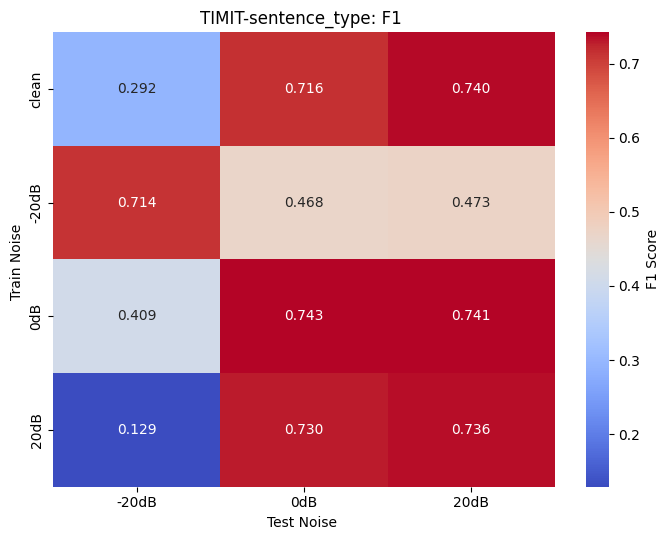

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 定义数据
train_conditions = ["clean", "-20dB", "0dB", "20dB"]
test_conditions = ["-20dB", "0dB", "20dB"]


# 添加干净训练的测试结果
values = np.array([
    [0.29222265004359355, 0.7161862794284763, 0.7402195443881782],  # Clean train
    [0.7138454800834301, 0.4678583546919213, 0.4726268895058703],    # Gaussian(neg20) train
    [0.4092137087915915, 0.7427364436748221, 0.7408558179385314],    # Gaussian(H) train
    [0.12900346626573586, 0.73035910687168, 0.7363988916054165]      # Gaussian(L) train
])

# 画heatmap
plt.figure(figsize=(7, 5.5))
sns.heatmap(values, annot=True, fmt=".3f", cmap="coolwarm",
            xticklabels=test_conditions, yticklabels=train_conditions,
            cbar_kws={'label': 'F1 Score'})

plt.title("TIMIT-sentence_type: F1 ")
plt.xlabel("Test Noise ")
plt.ylabel("Train Noise ")
plt.tight_layout()
plt.show()


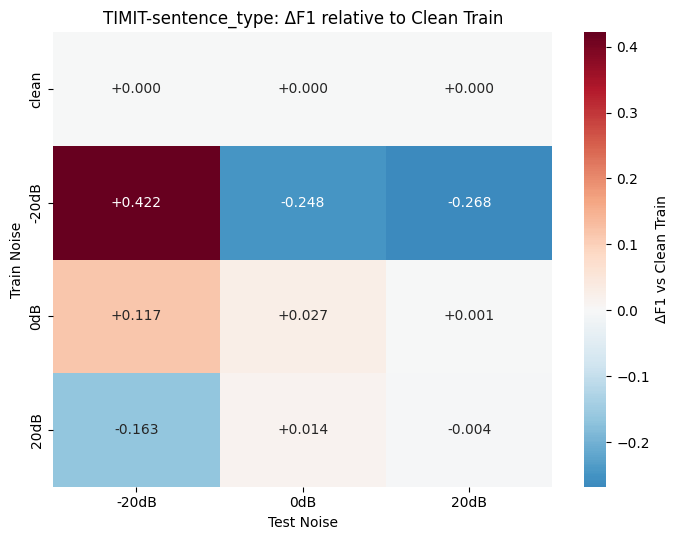


横纵比较分析：
1️⃣ 低噪情况下加噪声具有一定的泛化性：
    - 从0dB与20dB列可以看到，在这两个噪声级别下训练的模型表现接近甚至相互提升，说明中等噪声训练增强了鲁棒性。
2️⃣ 当噪声未达到严重程度时（≥0dB），噪声对模型性能影响较小：
    - 0dB与20dB训练行的表现差异仅约0.01~0.02。
3️⃣ 低噪训练（0dB）对高噪（-20dB）有一定泛化性：
    - 相比干净训练，0dB训练在-20dB测试时提升明显 (+0.12)。
4️⃣ 高噪训练（-20dB）损害低噪下的表现：
    - -20dB训练在高SNR（20dB）测试集下降显著 (-0.27)，说明过强噪声破坏了表征的区分性。



In [22]:
# 1️⃣ 计算相对clean的差值矩阵
diff_values = values - values[0]  # 每列相对clean训练的差值

# 画差值heatmap
plt.figure(figsize=(7, 5.5))
sns.heatmap(diff_values, annot=True, fmt="+.3f", cmap="RdBu_r", center=0,
            xticklabels=test_conditions, yticklabels=train_conditions,
            cbar_kws={'label': 'ΔF1 vs Clean Train'})

plt.title("TIMIT-sentence_type: ΔF1 relative to Clean Train")
plt.xlabel("Test Noise")
plt.ylabel("Train Noise")
plt.tight_layout()
plt.show()

# 2️⃣ 分析总结文本
analysis = """
横纵比较分析：
1️⃣ 低噪情况下加噪声具有一定的泛化性：
    - 从0dB与20dB列可以看到，在这两个噪声级别下训练的模型表现接近甚至相互提升，说明中等噪声训练增强了鲁棒性。
2️⃣ 当噪声未达到严重程度时（≥0dB），噪声对模型性能影响较小：
    - 0dB与20dB训练行的表现差异仅约0.01~0.02。
3️⃣ 低噪训练（0dB）对高噪（-20dB）有一定泛化性：
    - 相比干净训练，0dB训练在-20dB测试时提升明显 (+0.12)。
4️⃣ 高噪训练（-20dB）损害低噪下的表现：
    - -20dB训练在高SNR（20dB）测试集下降显著 (-0.27)，说明过强噪声破坏了表征的区分性。
"""
print(analysis)


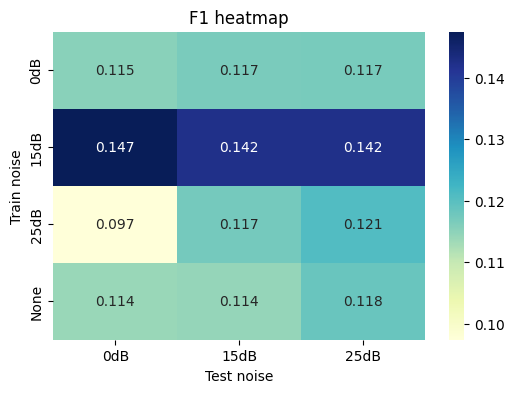

In [11]:
import seaborn as sns
pivot = df.pivot(index="train", columns="test", values="F1")

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("F1 heatmap")
plt.ylabel("Train noise")
plt.xlabel("Test noise")
plt.show()
